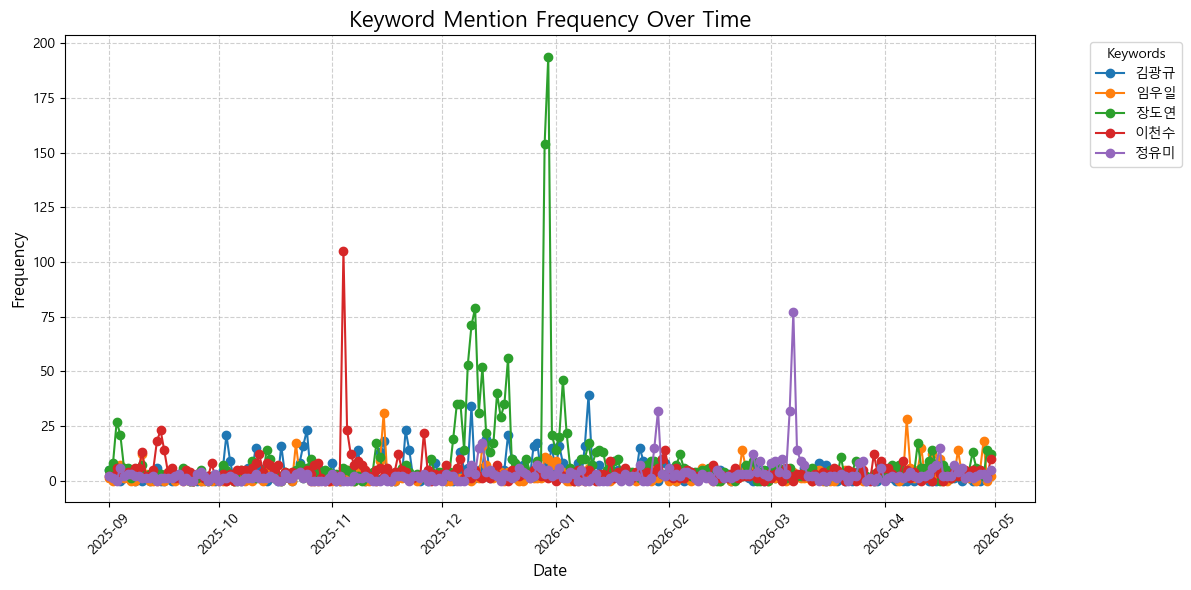

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Set up Korean font for Windows to prevent broken text in the legend
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. List of your CSV files (using 'r' before the string to handle Windows backslashes)
file_paths = [
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\0_김광규_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\0_임우일_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\0_장도연_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\2_이천수_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\2_정유미_list.csv"
]

# Set up the plot size
plt.figure(figsize=(12, 6))

# 3. Loop through each file, process, and plot
for path in file_paths:
    if os.path.exists(path):
        # Read only 'keyword' and 'time' to save memory
        df = pd.read_csv(path, usecols=['keyword', 'time'])
        
        # Grab the keyword name for the plot legend
        keyword_name = df['keyword'].iloc[0]
        
        # Convert the 'time' column to actual datetime objects
        # Your format: "2026.04.29 20:18"
        df['time'] = pd.to_datetime(df['time'], format='%Y.%m.%d %H:%M')
        
        # Set time as the index so we can resample it
        df.set_index('time', inplace=True)
        
        # Resample by Day ('D') and count the number of occurrences
        # You can change 'D' to 'W' for Weekly or 'M' for Monthly frequencies
        daily_frequency = df.resample('D').size()
        
        # Plot this specific keyword's frequency line
        plt.plot(daily_frequency.index, daily_frequency.values, marker='o', label=keyword_name)
    else:
        print(f"File not found: {path}")

# 4. Format the chart for readability
plt.title('Keyword Mention Frequency Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(title='Keywords', bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

# Adjust layout so the legend doesn't get cut off
plt.tight_layout()

# Display the plot
plt.show()

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

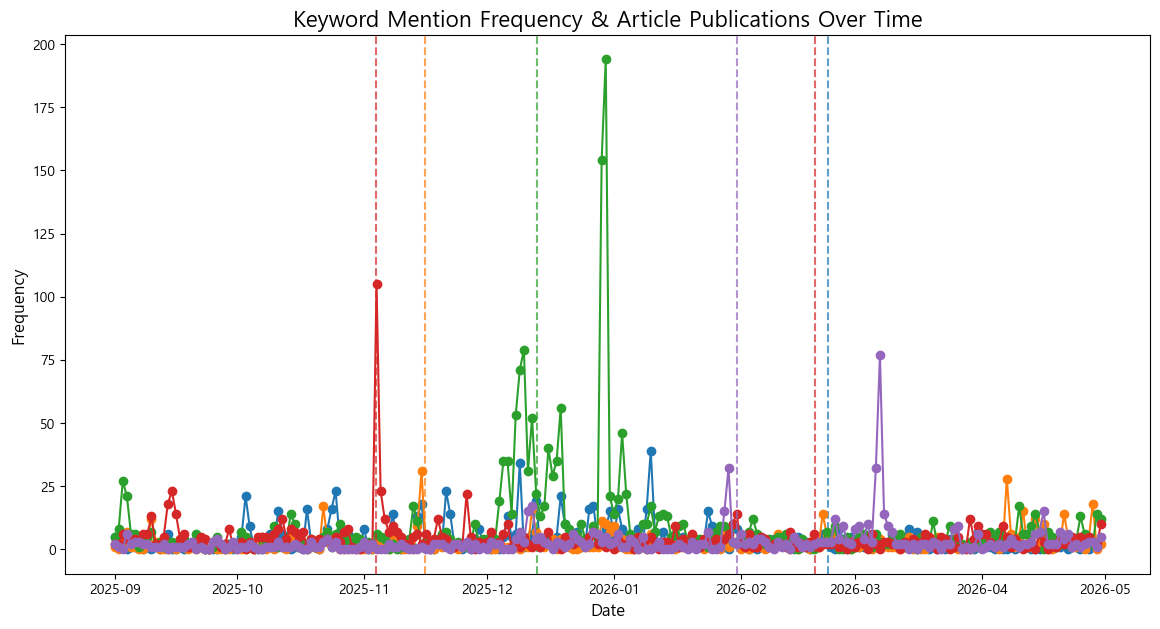

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Set up Korean font for Windows
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. File paths for your frequency data
file_paths = [
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\0_김광규_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\0_임우일_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\0_장도연_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\2_이천수_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\2_정유미_list.csv"
]

# 3. Path to your NEW article times CSV
# (Update this string to point to where you saved the new file)
article_csv_path = r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\name_article_time.csv"

# Load the article times and parse the dates (Format: YYYY-MM-DD-HH-MM)
articles_df = pd.read_csv(article_csv_path)
articles_df['article_time'] = pd.to_datetime(articles_df['article_time'], format='%Y-%m-%d-%H-%M')

# Set up the plot size
plt.figure(figsize=(14, 7))

# 4. Loop through each file, process, and plot
for path in file_paths:
    if os.path.exists(path):
        # Read the frequency data
        df = pd.read_csv(path, usecols=['keyword', 'time'])
        keyword_name = df['keyword'].iloc[0]
        
        # Parse the time and calculate daily frequency
        df['time'] = pd.to_datetime(df['time'], format='%Y.%m.%d %H:%M')
        df.set_index('time', inplace=True)
        daily_frequency = df.resample('D').size()
        
        # Plot the main frequency line
        # We add a comma after 'line' to unpack the list returned by plt.plot()
        line, = plt.plot(daily_frequency.index, daily_frequency.values, marker='o', label=keyword_name)
        
        # Grab the auto-assigned color of the line we just drew
        line_color = line.get_color()
        
        # 5. Find the article publication times for this specific person
        person_articles = articles_df[articles_df['name'] == keyword_name]
        
        # Draw a vertical line for each article publication
        for article_date in person_articles['article_time']:
            plt.axvline(x=article_date, color=line_color, linestyle='--', alpha=0.7, linewidth=1.5)
            
            # Optional: If you also want a little star at the bottom of the chart to mark it:
            # plt.scatter(article_date, 0, color=line_color, s=150, marker='*', zorder=5)

    else:
        print(f"File not found: {path}")

# 6. Format the chart
plt.title('Keyword Mention Frequency & Article Publications Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Move legend outside the plot so it doesn't cover your data or the vertical lines
plt.legend

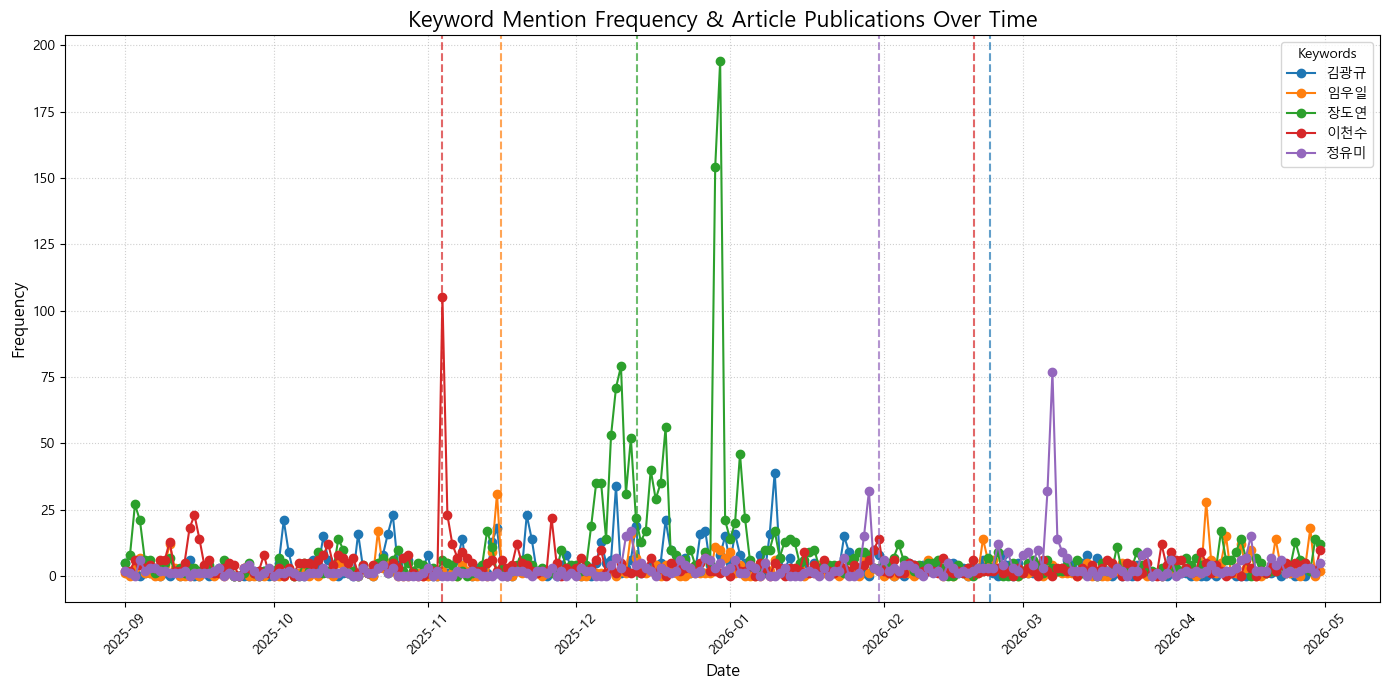

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Set up Korean font for Windows
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. File paths for your frequency data
file_paths = [
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\0_김광규_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\0_임우일_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\0_장도연_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\2_이천수_list.csv",
    r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\2_정유미_list.csv"
]

# 3. Path to your NEW article times CSV
article_csv_path = r"C:\Users\WINDOWS 11\Desktop\kpop_agenda\Step2\name_article_time.csv"

# Load the article times and parse the dates
articles_df = pd.read_csv(article_csv_path)
articles_df['article_time'] = pd.to_datetime(articles_df['article_time'], format='%Y-%m-%d-%H-%M')

# Set up the plot size
plt.figure(figsize=(14, 7))

# 4. Loop through each file, process, and plot
for path in file_paths:
    if os.path.exists(path):
        # Read the frequency data
        df = pd.read_csv(path, usecols=['keyword', 'time'])
        keyword_name = df['keyword'].iloc[0]
        
        # Parse the time and calculate daily frequency
        df['time'] = pd.to_datetime(df['time'], format='%Y.%m.%d %H:%M')
        df.set_index('time', inplace=True)
        daily_frequency = df.resample('D').size()
        
        # Plot the main frequency line
        line, = plt.plot(daily_frequency.index, daily_frequency.values, marker='o', label=keyword_name)
        
        # Grab the auto-assigned color of the line
        line_color = line.get_color()
        
        # 5. Find the article publication times for this specific person
        person_articles = articles_df[articles_df['name'] == keyword_name]
        
        # Draw a vertical line for each article publication
        for article_date in person_articles['article_time']:
            plt.axvline(x=article_date, color=line_color, linestyle='--', alpha=0.7, linewidth=1.5)

    else:
        print(f"File not found: {path}")

# 6. Format the chart
plt.title('Keyword Mention Frequency & Article Publications Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# FIX: Keep the legend inside the plot area at the top right
plt.legend(title='Keywords', loc='upper right')

plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()